In [50]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
import os


In [51]:
model = ChatGroq(
    api_key=os.environ.get("GROQ_API_KEY"),
    model="llama-3.1-8b-instant")

In [52]:
class jokestate(TypedDict):
    topic : str
    joke : str
    explanation : str

In [53]:
def generate_joke(state: jokestate):
    prompt = f"generate a joke on the topic {state['topic']}"
    
    response = model.invoke(prompt).content
    
    return {"joke": response}

In [54]:
def explain_joke(state: jokestate):
    prompt = f"explain the joke that is  {state['joke']}"
    
    response = model.invoke(prompt).content
    
    return {"explanation": response}

In [55]:
graph = StateGraph(jokestate)

graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

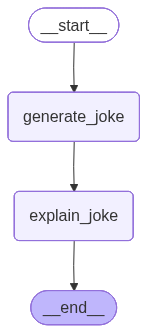

In [56]:
workflow

In [57]:
config1 = {
    "configurable": {
        "thread_id": "1"
    }
}

In [58]:
workflow.invoke({'topic':'pizza'},config = config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, which is a common type of humor. It\'s a pun, a form of wordplay that exploits multiple meanings of a word or phrase.\n\nIn this joke, the word "crusty" has two related meanings:\n\n1. A pizza crust is the hard outer layer of a pizza, a characteristic feature of the food.\n2. To be "feeling a little crusty" is an idiomatic expression that means to be feeling irritable, grumpy, or a bit upset.\n\nThe joke is funny because it takes the literal meaning of "crusty" (referring to the pizza crust) and applies it to the idiomatic expression, creating a clever and unexpected connection between the two meanings. This unexpected twist creates the humor.\n\nSo, in essence, the joke is saying that the pizza is feeling irritable (crusty) because it\'s a pizza, and it\'s a clever play on words that creates the humor.'}

In [59]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, which is a common type of humor. It\'s a pun, a form of wordplay that exploits multiple meanings of a word or phrase.\n\nIn this joke, the word "crusty" has two related meanings:\n\n1. A pizza crust is the hard outer layer of a pizza, a characteristic feature of the food.\n2. To be "feeling a little crusty" is an idiomatic expression that means to be feeling irritable, grumpy, or a bit upset.\n\nThe joke is funny because it takes the literal meaning of "crusty" (referring to the pizza crust) and applies it to the idiomatic expression, creating a clever and unexpected connection between the two meanings. This unexpected twist creates the humor.\n\nSo, in essence, the joke is saying that the pizza is feeling irritable (crusty) because it\'s a pizza, and it\'s a clever play on words that creates the humor.'}, next=(),

TIME TRAVEL

In [60]:
workflow.get_state({'configurable' : {'thread_id':'1', 'checkpoint_id ': '1f17b8fe-543b-6946-8001-dba76605d3b8'}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, which is a common type of humor. It\'s a pun, a form of wordplay that exploits multiple meanings of a word or phrase.\n\nIn this joke, the word "crusty" has two related meanings:\n\n1. A pizza crust is the hard outer layer of a pizza, a characteristic feature of the food.\n2. To be "feeling a little crusty" is an idiomatic expression that means to be feeling irritable, grumpy, or a bit upset.\n\nThe joke is funny because it takes the literal meaning of "crusty" (referring to the pizza crust) and applies it to the idiomatic expression, creating a clever and unexpected connection between the two meanings. This unexpected twist creates the humor.\n\nSo, in essence, the joke is saying that the pizza is feeling irritable (crusty) because it\'s a pizza, and it\'s a clever play on words that creates the humor.'}, next=(), 

In [61]:
workflow.invoke(None, {'configurable' : {'thread_id':'1', 'checkpoint_id ': '1f17b8ce-af6f-6c5c-8000-37a8585bd456' }})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, which is a common type of humor. It\'s a pun, a form of wordplay that exploits multiple meanings of a word or phrase.\n\nIn this joke, the word "crusty" has two related meanings:\n\n1. A pizza crust is the hard outer layer of a pizza, a characteristic feature of the food.\n2. To be "feeling a little crusty" is an idiomatic expression that means to be feeling irritable, grumpy, or a bit upset.\n\nThe joke is funny because it takes the literal meaning of "crusty" (referring to the pizza crust) and applies it to the idiomatic expression, creating a clever and unexpected connection between the two meanings. This unexpected twist creates the humor.\n\nSo, in essence, the joke is saying that the pizza is feeling irritable (crusty) because it\'s a pizza, and it\'s a clever play on words that creates the humor.'}

In [62]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, which is a common type of humor. It\'s a pun, a form of wordplay that exploits multiple meanings of a word or phrase.\n\nIn this joke, the word "crusty" has two related meanings:\n\n1. A pizza crust is the hard outer layer of a pizza, a characteristic feature of the food.\n2. To be "feeling a little crusty" is an idiomatic expression that means to be feeling irritable, grumpy, or a bit upset.\n\nThe joke is funny because it takes the literal meaning of "crusty" (referring to the pizza crust) and applies it to the idiomatic expression, creating a clever and unexpected connection between the two meanings. This unexpected twist creates the humor.\n\nSo, in essence, the joke is saying that the pizza is feeling irritable (crusty) because it\'s a pizza, and it\'s a clever play on words that creates the humor.'}, next=(),